In [34]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path(r"C:\Users\Hector Lopez\Desktop\Py_Projects\Life_Insurance_Project\data\tables")

# list of (filename, risk_class, gender)
FILES = [
    ("2015 VBT Male RR80.xls", "preferred", "male"),
    ("2015 VBT Male RR60.xls", "superpreferred", "male"),
    ("2015 VBT Male RR100.xls", "standard", "male"),
    ("2015 VBT Female RR80.xls", "preferred", "female"),
    ("2015 VBT Female RR60.xls", "superpreferred", "female"),
    ("2015 VBT Female RR100.xls", "standard", "female"),
]

def read_excel(path: Path, risk_class: str, gender: str):
    """Read an Excel file and add annotation columns."""
    df = pd.read_excel(path)
    df["risk_class"] = risk_class
    df["gender"] = gender
    return df

# sequential read + concat
dfs = []
for fname, risk, gender in FILES:
    p = DATA_DIR / fname
    dfs.append(read_excel(p, risk, gender))
combined = pd.concat(dfs, ignore_index=True)

In [35]:
df = combined.copy()


In [36]:

def get_insured_info(df: pd.DataFrame, age: float, risk_class: str, gender: 'str')-> np.ndarray:

    mask = (df["risk_class"].eq(risk_class)) & (df["gender"].eq(gender)) & (df["issue_age"].eq(age))

    insured_data = df.loc[mask].drop(columns=["risk_class", "gender", "issue_age"])

    if insured_data.empty:
        raise ValueError(
            "No mortality data found for "
            f"age={age}, risk_class='{risk_class}', gender='{gender}'."
            )
        
    return insured_data.values[0]

In [37]:
def set_term_length(term_duration: float, q_values: np.array)-> np.ndarray:

    if term_duration <= 0:
        raise ValueError("Term duration must be greater than zero.")
    
    if term_duration > q_values.size:
        raise ValueError(
        f"Term duration is {term_duration}, but only "
        f"{q_values.size} q-values are available."
        )
    
    return q_values[:term_duration]


In [38]:
def calc_death_prob(q_term: np.array)-> tuple[np.ndarray, np.ndarray]:

    survival_before = np.empty_like(q_term, dtype=float)
    survival_before[0] = 1.0

    if len(q_term) > 1:
        survival_before[1:] = np.cumprod(1.0 - q_term)[:-1]

    prob_dying = survival_before * q_term  

    return np.round(survival_before,7), np.round(prob_dying,7)

In [39]:
def calc_APV_annuity_due(survival_before: np.array, discount_rate: float)-> float:

    discount = (1 + discount_rate) ** (-np.arange(len(survival_before)))  

    return float(np.dot(survival_before, discount))


In [40]:
def calc_APV(probability_dying: np.array, discount_rate: float)-> float:
##The Actuarial Present Value is the expected value of the present value random variable (Z) associated with the future insurance payout
    discount = (1 + discount_rate) **(-np.arange(1, len(probability_dying) + 1))   

    return float(sum(probability_dying*discount))


In [41]:
def calculate_prem(face_amount: float, APV_annuity_due: float, APV: float)-> float:

    return (APV/APV_annuity_due)*face_amount

In [42]:
def get_results(
                df: pd.DataFrame,
                age: int,
                risk_class: str,
                gender: str,
                term_duration: int,
                face_amount: float,
                discount_rate: float,
                ) -> float:

    q_values = get_insured_info(df=df, age=age, risk_class=risk_class, gender=gender)

    q_term = set_term_length( q_values=q_values, term_duration=term_duration)
     
    survival_before, probability_dying = calc_death_prob(q_term=q_term)
    
    pv_expected_premiums = calc_APV_annuity_due(survival_before=survival_before, discount_rate=discount_rate)
    
    pv_benefits_payable = calc_APV(probability_dying=probability_dying, discount_rate = discount_rate)

    pure_prem = calculate_prem(face_amount=face_amount, APV_annuity_due= pv_expected_premiums, APV= pv_benefits_payable)

    return {'mortality': q_term,
            'px': survival_before, 
             'qxt': probability_dying,
            'apv': pv_benefits_payable,
            'apv_ann_due': pv_expected_premiums,
            'pure_prem': round(pure_prem,2)       
            }

In [43]:
def calc_gross_prem(results: dict, expense_ratio: float, policy_fee: float, yr1_acquisition_cost: float):

    acqcost = round(yr1_acquisition_cost/results['apv_ann_due'],2)
    expenseload = 1-expense_ratio
    
    grossprem = round((results['pure_prem']+ policy_fee + acqcost)/(expenseload),2)

    return grossprem

In [66]:
face_amount = 3360000
discount_rate = .05
expense_ratio = .10
policy_fee =50
yr1_acquisition_cost = 500

ages = np.arange(24, 62, step=2)
risk_classes = list(df.risk_class.unique())

combinations = [(age, risk_class) for age in ages for risk_class in risk_classes]
results = []


for age, rsk_cls in combinations:
    for gender in ['male', 'female']:

        values = get_results(df = df, age = age, risk_class= rsk_cls, gender= gender, term_duration=20, face_amount=face_amount, discount_rate=discount_rate)
        values['age'] = age
        values['gender'] = gender
        values['risk_class'] = rsk_cls
        values['grossprem'] = calc_gross_prem(values, expense_ratio, policy_fee, yr1_acquisition_cost)

        results.append(values)

    

In [67]:
def calc_gross_prem(results: dict, expense_ratio: float, policy_fee: float, yr1_acquisition_cost: float):

    acqcost = round(yr1_acquisition_cost/results['apv_ann_due'],2)
    expenseload = 1-expense_ratio
    
    grossprem = round((results['pure_prem']+ policy_fee + acqcost)/(expenseload),2)

    return grossprem

In [68]:
prem_df = pd.DataFrame(results).sort_values(['age','pure_prem']).reset_index(drop=True)
prem_df.head()


,mortality,px,qxt,apv,apv_ann_due,pure_prem,age,gender,risk_class,grossprem
0,"[9e-05, 0.00012, 0.00012, 0.00012, 0.00012, 0....","[1.0, 0.99991, 0.99979, 0.99967, 0.9995501, 0....","[9e-05, 0.00012, 0.00012, 0.00012, 0.0001199, ...",0.002936,13.067410,754.80,24,female,superpreferred,936.73
1,"[0.00011, 0.00014, 0.00014, 0.00014, 0.00015, ...","[1.0, 0.99989, 0.99975, 0.9996101, 0.9994701, ...","[0.00011, 0.00014, 0.00014, 0.0001399, 0.00014...",0.003515,13.063900,904.01,24,female,preferred,1102.53
2,"[0.00013, 0.00016, 0.00016, 0.00016, 0.00017, ...","[1.0, 0.99987, 0.99971, 0.9995501, 0.9993901, ...","[0.00013, 0.00016, 0.00016, 0.0001599, 0.00016...",0.004047,13.060676,1041.04,24,female,standard,1254.80
3,"[0.00023, 0.00024, 0.00021, 0.00021, 0.0002, 0...","[1.0, 0.99977, 0.9995301, 0.9993202, 0.9991103...","[0.00023, 0.0002399, 0.0002099, 0.0002099, 0.0...",0.004115,13.058297,1058.78,24,male,superpreferred,1274.52
4,"[0.00028, 0.00028, 0.00026, 0.00025, 0.00025, ...","[1.0, 0.99972, 0.9994401, 0.9991802, 0.9989304...","[0.00028, 0.0002799, 0.0002599, 0.0002498, 0.0...",0.004970,13.052661,1279.47,24,male,preferred,1519.76


In [69]:
prem_df[prem_df['age'] == 40]

,mortality,px,qxt,apv,apv_ann_due,pure_prem,age,gender,risk_class,grossprem
48,"[8e-05, 0.00012, 0.00019, 0.00025, 0.0003, 0.0...","[1.0, 0.99992, 0.9998, 0.99961, 0.9993601, 0.9...","[8e-05, 0.00012, 0.00019, 0.0002499, 0.0002998...",0.006941,13.046689,1787.48,40,female,superpreferred,2084.22
49,"[9e-05, 0.00015, 0.00022, 0.00026, 0.0003, 0.0...","[1.0, 0.99991, 0.99976, 0.9995401, 0.9992802, ...","[9e-05, 0.00015, 0.0002199, 0.0002599, 0.00029...",0.007773,13.042957,2002.35,40,male,superpreferred,2322.98
50,"[0.00011, 0.00017, 0.00027, 0.00035, 0.00042, ...","[1.0, 0.99989, 0.99972, 0.9994501, 0.9991003, ...","[0.00011, 0.00017, 0.0002699, 0.0003498, 0.000...",0.009552,13.031449,2462.93,40,female,preferred,2834.78
51,"[0.00013, 0.00023, 0.00033, 0.00039, 0.00045, ...","[1.0, 0.99987, 0.99964, 0.9993101, 0.9989204, ...","[0.00013, 0.00023, 0.0003299, 0.0003897, 0.000...",0.011185,13.023260,2885.73,40,male,preferred,3304.58
52,"[0.00013, 0.00021, 0.00032, 0.00042, 0.00051, ...","[1.0, 0.99987, 0.99966, 0.9993401, 0.9989204, ...","[0.00013, 0.00021, 0.0003199, 0.0004197, 0.000...",0.011459,13.020444,2957.12,40,female,standard,3383.91
53,"[0.00017, 0.0003, 0.00043, 0.00051, 0.00059, 0...","[1.0, 0.99983, 0.9995301, 0.9991003, 0.9985907...","[0.00017, 0.0002999, 0.0004298, 0.0005095, 0.0...",0.014445,13.004517,3732.10,40,male,standard,4245.06


In [70]:
import seaborn as sns
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import matplotlib.pyplot as plt

def gender_barplot(df:pd.DataFrame, gender: str):

    filtered_df = df[df["gender"] == gender]

    if gender == 'male':
        colors =[ "#85C6C9", "#16C8F5", "#0C85E7"]
    else: 
        colors = ['pink', 'hotpink', 'violet']

    plt.figure(figsize=(14, 6))

    sns.barplot(
        data=filtered_df,
        x="age",
        y="pure_prem",
        hue="risk_class",
        errorbar=None,
        palette = colors, 
        width=.8
        )

    plt.title(f"{gender.title()}, ${face_amount:,}, 20-Year Term, Pure Premium", weight = 'bold', fontfamily = 'serif')
    plt.xlabel("Issue Age", fontfamily = 'serif')

    max = int(filtered_df["pure_prem"].max())

    scale_step = round((max/10)/500)*500

    plt.ylabel("Premium", fontfamily = 'serif')
    plt.yticks(np.arange(0, max, step= scale_step))

    plt.legend(labels = ["Super Preferred", 'Preferred', 'Standard'], loc= 'upper center', bbox_to_anchor=(0.5, 1.0), ncols=3, frameon = False)
    plt.tight_layout()
    plt.show()



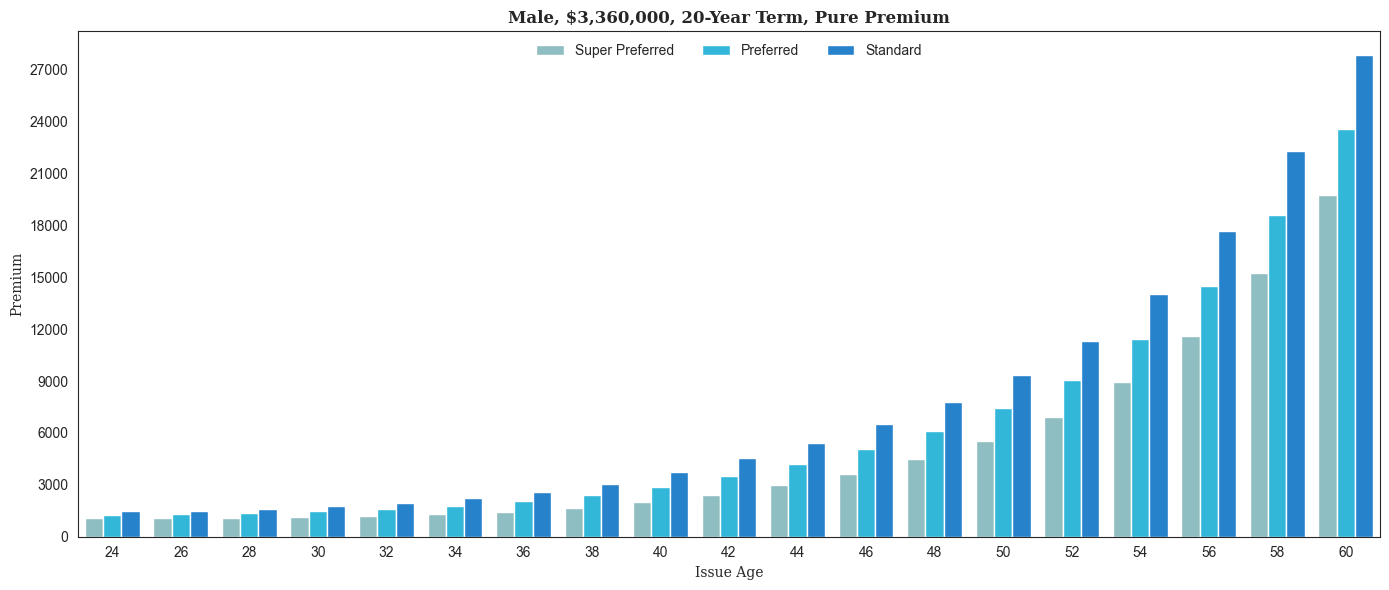

In [71]:
gender_barplot(prem_df, 'male')

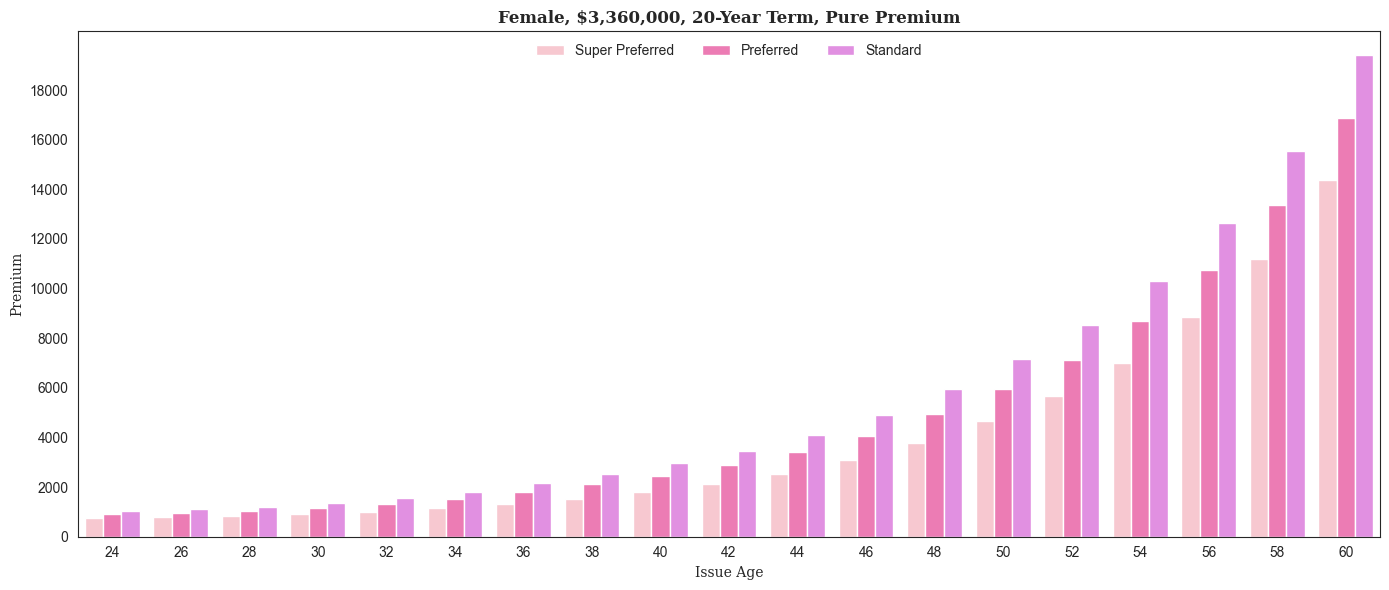

In [72]:
gender_barplot(prem_df, 'female')

In [73]:
sns.set_style('white')

def plot_perctdiff(df:pd.DataFrame, riskclass: str, premium: str, ax):
    filtered_df = (
                    df.loc[prem_df["risk_class"].eq(riskclass)]
                    .copy()
                    )
    
    # Calculate age-to-age percentage change by gender
    filtered_df["perc_diff"] = (
                    filtered_df.groupby("age")[premium]
                    .pct_change()
                    .mul(100)
                    .round(2)
                    )
                    
    df_pct = filtered_df[['age', 'perc_diff']].dropna(subset=["perc_diff"]).copy()
    
    # Bar plots treat age as a categorical variable, so map each age
    # to its corresponding categorical x-axis position.
    age_order = sorted(filtered_df["age"].unique())
    age_positions = {age: position for position, age in enumerate(age_order)}
    
    df_pct["age_position"] = df_pct["age"].map(age_positions)
    
    sns.lineplot(
                data=df_pct,
                x="age_position",
                y="perc_diff",
                marker="o",
                ax=ax,
                color = 'red',
                legend=False
                )
    
    
    max = int(df_pct['perc_diff'].max()) 
    scale_step = round((max/11)/5)*5
    
    ax.set_ylabel("Premium Difference (%)", fontfamily="serif")
    ax.set_yticks(np.arange(0, max + 10, step= scale_step))
    ax.legend(labels = ['Male Premium Above Female (%)'], loc= 'upper center', bbox_to_anchor=(0.5,.95), ncols=1, frameon = False)
    
    return ax

In [74]:

def riskclass_viz(df: pd.DataFrame, riskclass: str, gross_prem = False, percent_diff = False):

    filtered_df = df[df["risk_class"] == riskclass]

    fig, ax1 = plt.subplots(figsize=(16, 6))

    if gross_prem:
        premium = 'grossprem'
        label = 'Gross Premium'
    else: 
        premium = 'pure_prem'
        label = 'Pure Premium'

    sns.barplot(
        data=filtered_df,
        x="age",
        y= premium,
        hue="gender",
        errorbar=None,
        palette = ['hotpink', 'dodgerblue'],
        ax = ax1
        )

    if percent_diff:
        ax2= ax1.twinx()
        plot_perctdiff(df= filtered_df, riskclass= riskclass, premium = premium, ax= ax2)

    if riskclass == 'superpreferred':
        riskclass = 'Super Preferred'
        
    ax1.set_title(f"{riskclass.title()}, ${face_amount:,}, 20-Year Term, {label}", weight = 'bold', fontfamily = 'serif')
    ax1.legend(labels = ['Female', 'Male'], loc= 'upper center', bbox_to_anchor=(0.5, 1.0), ncols=2, frameon = False)

    ax1.set_xlabel("Issue Age", fontfamily = 'serif')
    ax1.set_xlim(-0.50, len(filtered_df["age"].unique()) - 0.45)

    max = int(filtered_df[premium].max()) 
    scale_step = round((max/10)/500)*500

    ax1.set_ylabel("Premium", fontfamily = 'serif')
    ax1.set_yticks(np.arange(0, max + 4000, step= scale_step))

    
    fig.tight_layout()
    plt.show()

    return 


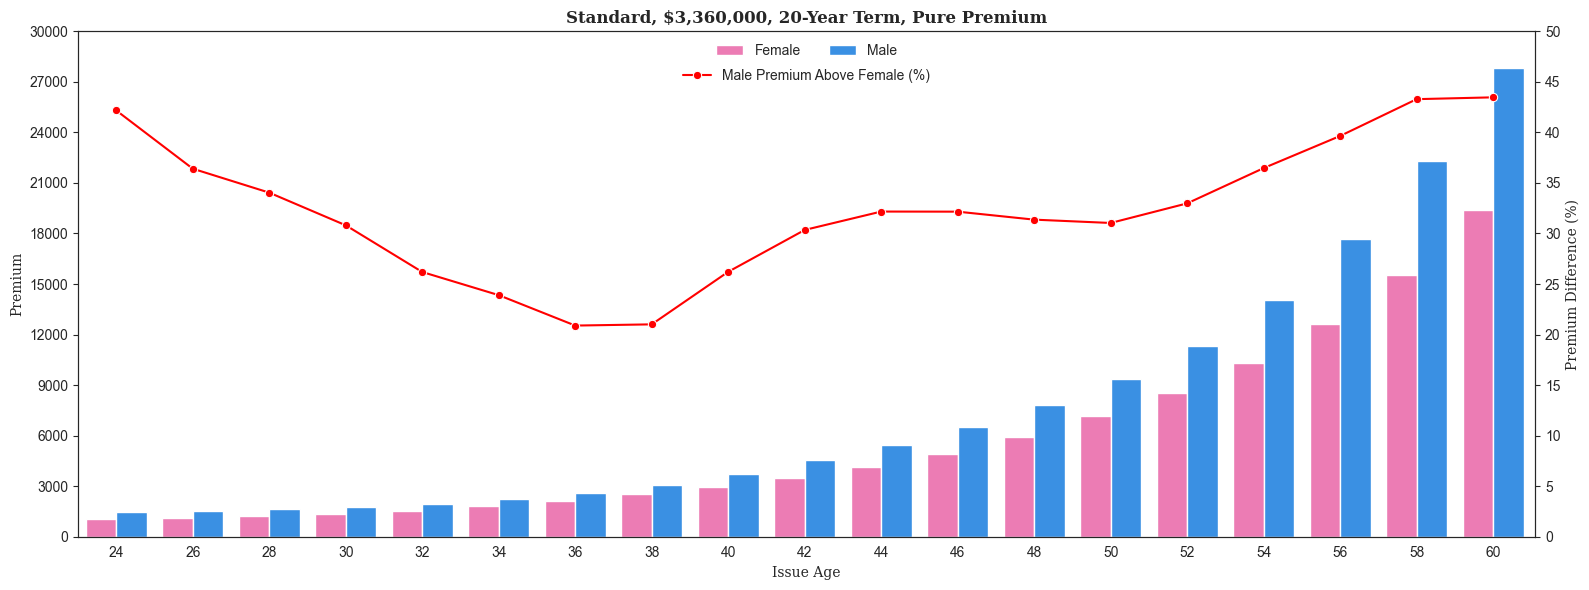

In [75]:
riskclass_viz(prem_df, 'standard', percent_diff= True)

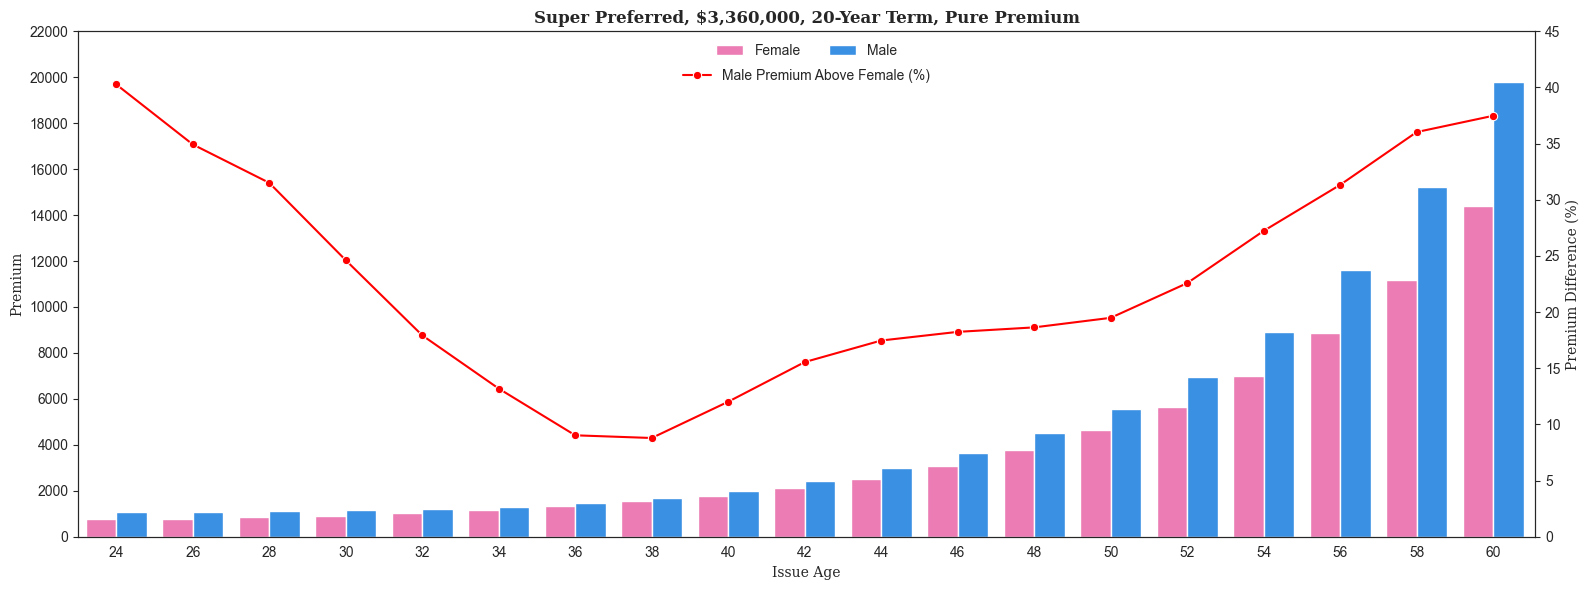

In [76]:
riskclass_viz(prem_df, 'superpreferred', percent_diff= True)

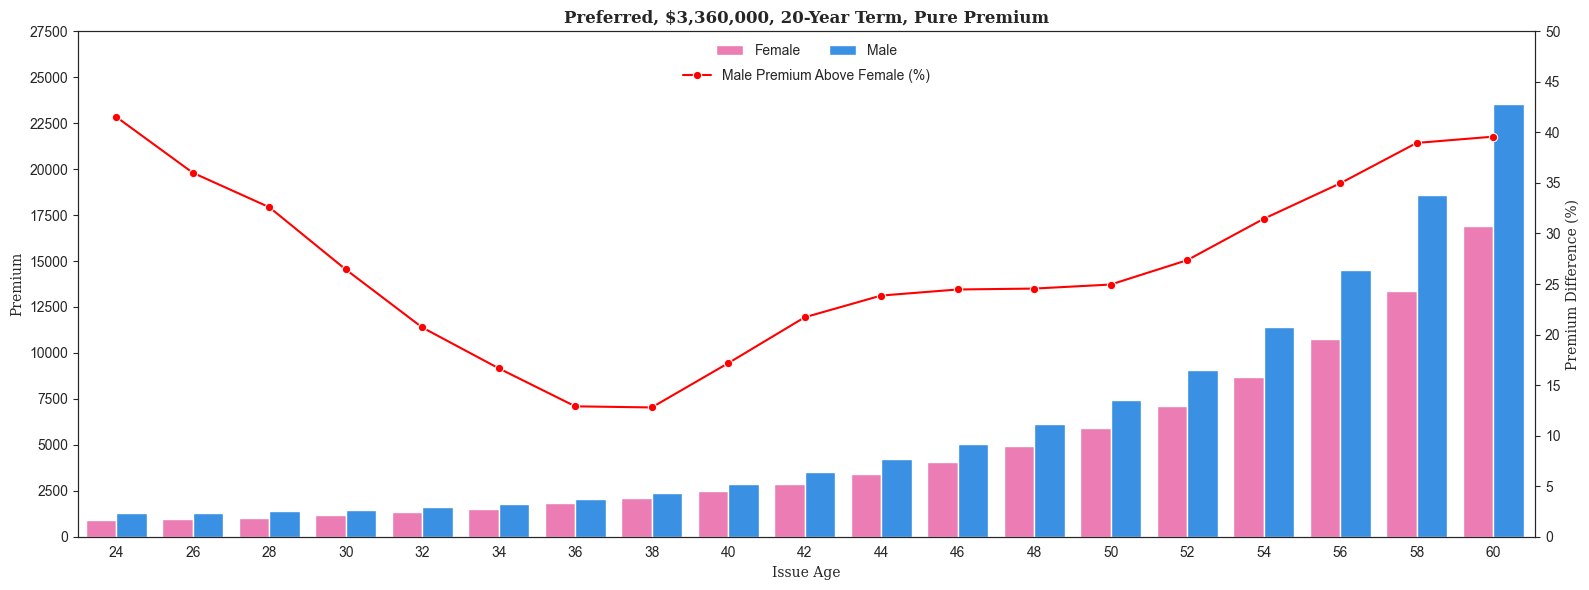

In [77]:
riskclass_viz(prem_df, 'preferred', percent_diff= True)

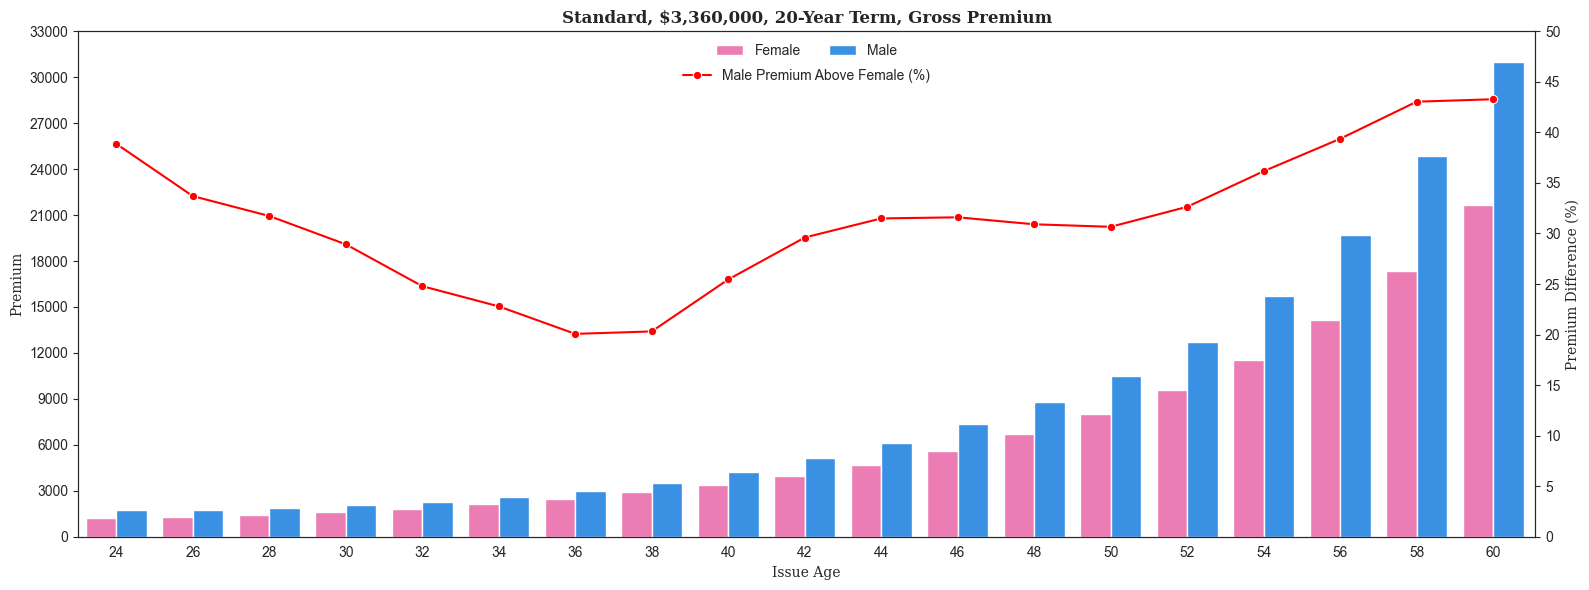

In [78]:
riskclass_viz(prem_df, 'standard', gross_prem= True, percent_diff= True)

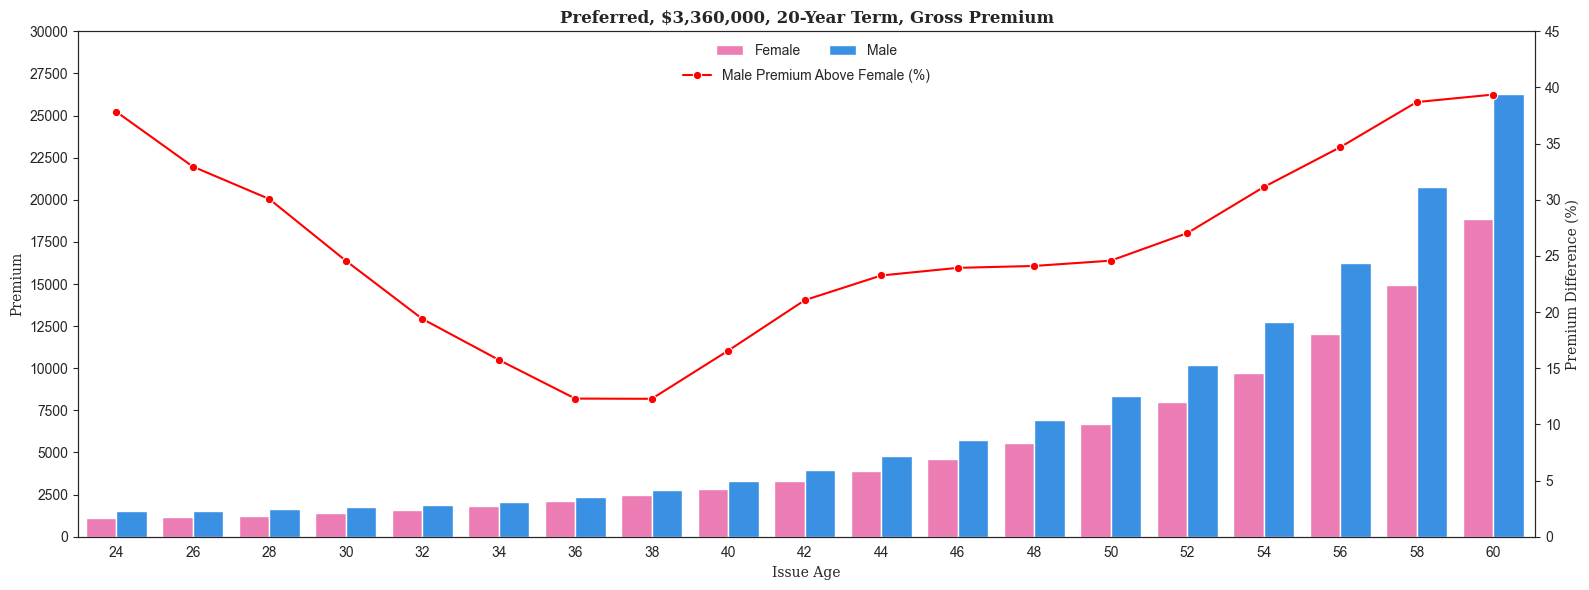

In [79]:
riskclass_viz(prem_df, 'preferred', gross_prem= True, percent_diff= True)

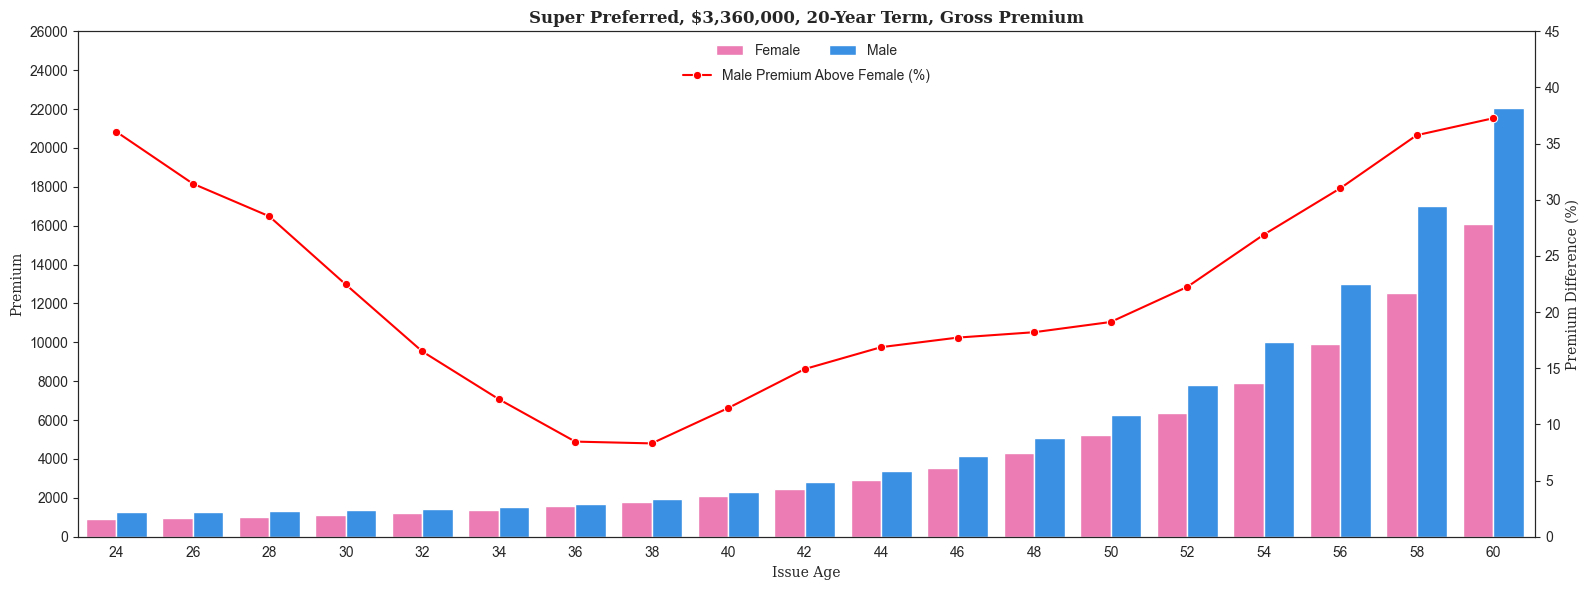

In [80]:
riskclass_viz(prem_df, 'superpreferred', gross_prem= True, percent_diff= True)

In [81]:
def reserves(df: pd.DataFrame, age: float, risk: str, gender: str, termdur: float, benefit: float, int_r: float):

    mask = (df['age'] == age) & (df['risk_class'] == risk) & (df['gender'] == gender)

    insuredval = df.loc[mask]

    px = insuredval["px"].values[0]
    qx = insuredval["qxt"].values[0]
    pure_prem = insuredval["pure_prem"].values[0]

    v = 1 / (1+ int_r)

    res_t = []
    reserve_dict = {}

    npv_prem = []
    npv_bene = []

    for t in range(len(qx)):
        
        npv_benefits = 0
        npv_premiums = 0

        for k in range(t, len(qx)):
                        
            npv_benefits += benefit * qx[k] * v ** (k - t + 1)
            npv_premiums += px[k] * pure_prem* v ** (k - t)

        

        res = round(npv_benefits - npv_premiums, 2)
        npv_bene.append(npv_benefits)
        npv_prem.append(npv_premiums)

        if res <0: 
            res = 0
            res_t.append(res)
        else: 
            res_t.append(res)
        

    reserve_dict[age] = res_t

    return reserve_dict, npv_prem, npv_bene

In [82]:
from math import ceil
def plot_term_reserves(
        prem_df,
        age,
        risk_class,
        gender,
        term_duration,
        benefit_amount,
        interest_rate
        ):

        # Run reserve calculation
        reserve_df, prem_npv, bene_npv = reserves(prem_df, age, risk_class, gender, term_duration, benefit_amount, interest_rate)
        reserve_values = reserve_df[age]

        x_values = np.arange(len(prem_npv))
        width = 0.4

        max_idx = np.argmax(reserve_values)
        max_reserve = reserve_values[max_idx]

        sns.set_style("white")
        #sns.set_theme("notebook", font_scale=.9 )

        fig, (ax1, ax2) = plt.subplots(nrows=2,figsize=(12, 10))

        # ------------------
        # NPV Bar Chart
        # ------------------
        ax1.bar(x_values - width / 2, prem_npv, width=width,
                color="dodgerblue",
                label="NPV Future Premiums"
                )

        ax1.bar(x_values + width / 2, bene_npv,
                width=width,
                color="navy",
                label="NPV Future Death Benefits"
                )

        ax1.set_xlabel(
                "Policy Year",
                fontsize=10,
                fontfamily="serif"
                )

        ax1.set_xticks(x_values)
        ax1.set_xticklabels(np.arange(1, len(prem_npv) + 1))
        ax1.set_xlim(-0.5, len(prem_npv) - 0.5)

        ax1.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15),
                ncols=2,
                frameon=False, fontsize = 10
                )

        # ------------------
        # Reserve Line Plot
        # ------------------
        sns.lineplot(x=x_values, y=reserve_values,
        marker="o", color="#85a1b8", ax=ax2
        )

        ax2.plot(max_idx, max_reserve,
                marker="o", color="red",
                markersize=6
                
                )


        ax2.set_xticks(x_values)
        ax2.set_xticklabels(np.arange(1, len(prem_npv) + 1))

        if 100000 < max_reserve:
                scale_step = ceil((max_reserve/10)/20000)*20000
                label_offset = 10000


        elif 50000 <= max_reserve <= 100000:
                scale_step = ceil((max_reserve/10)/5000)*5000
                label_offset = 5000

                
        elif  30000 <= max_reserve < 50000:
                scale_step = ceil((max_reserve/10)/2000)*2000
                label_offset = 2000

                
        elif max_reserve < 30000:
                scale_step = ceil((max_reserve/10)/500)*500
                label_offset = 500

                
        ax2.set_yticks(
        np.arange(0, max_reserve + scale_step, scale_step)
        )

        
        ax2.annotate(
                f"${max_reserve:,.2f}",
                xy=(max_idx, max_reserve),
                xytext=(max_idx, max_reserve + label_offset),
                color="red",
                fontsize=9,
                ha="center",
                )

        ax2.set_xlabel("Policy Year",
                fontsize=10,
                fontfamily="serif"
                )

        ax2.set_title( f"{term_duration}-Year Term Insurance Net Premium Reserve\n",
                        fontsize = 10
                        )

        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)

        plt.subplots_adjust(hspace=.6)

        return 

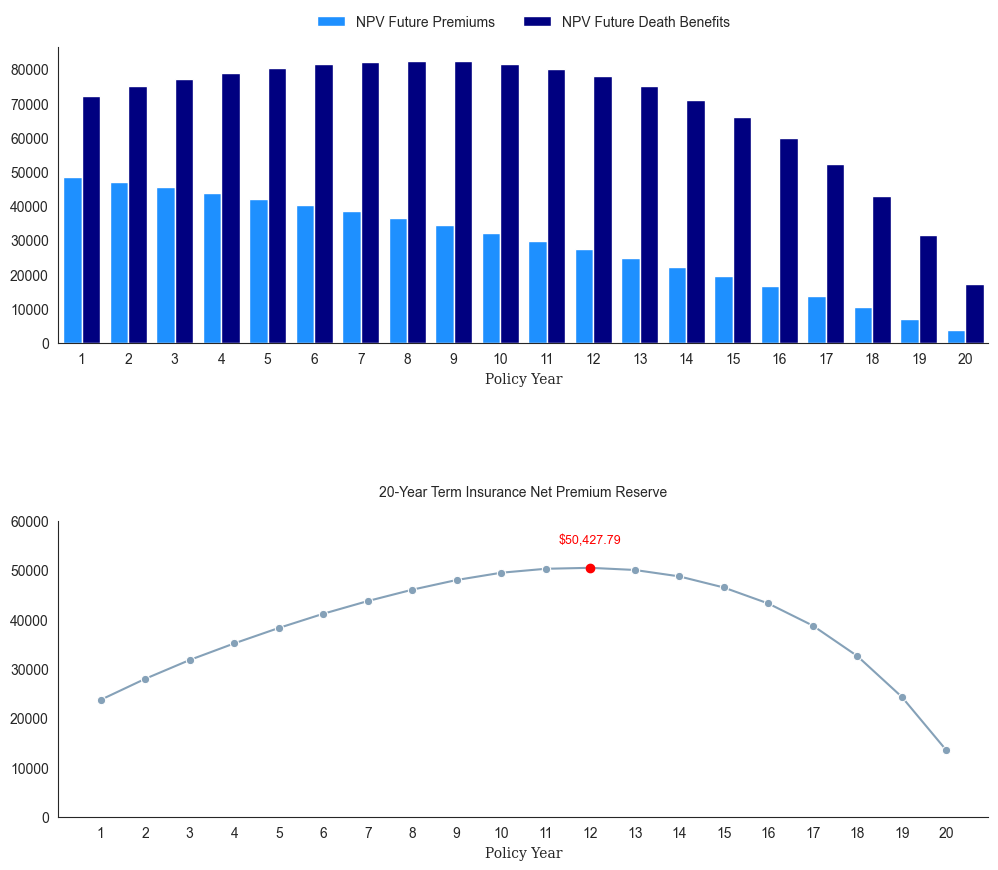

In [83]:
plot_term_reserves(prem_df, 40, 'standard', 'male', 20, 5000000, 0.05)

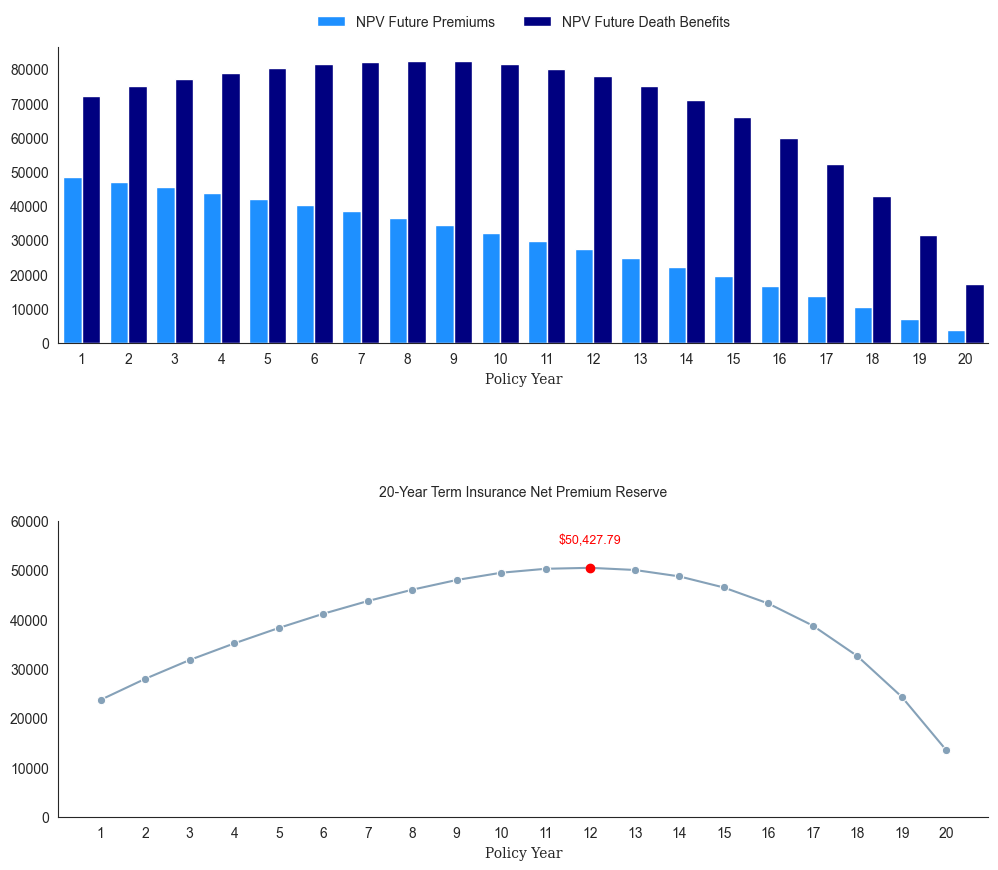

In [84]:
plot_term_reserves(prem_df, 40, 'standard', 'male', 20, 5000000, 0.05)

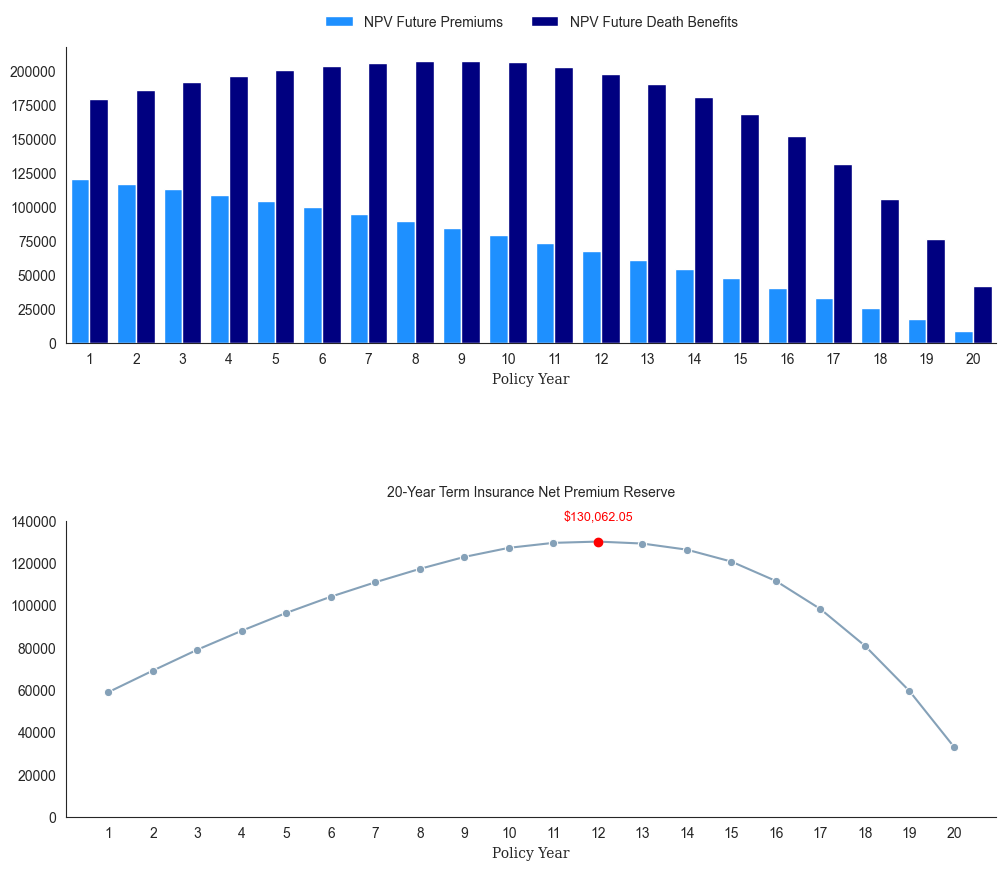

In [85]:
plot_term_reserves(prem_df, 50, 'standard', 'male', 20, 5000000, 0.05)

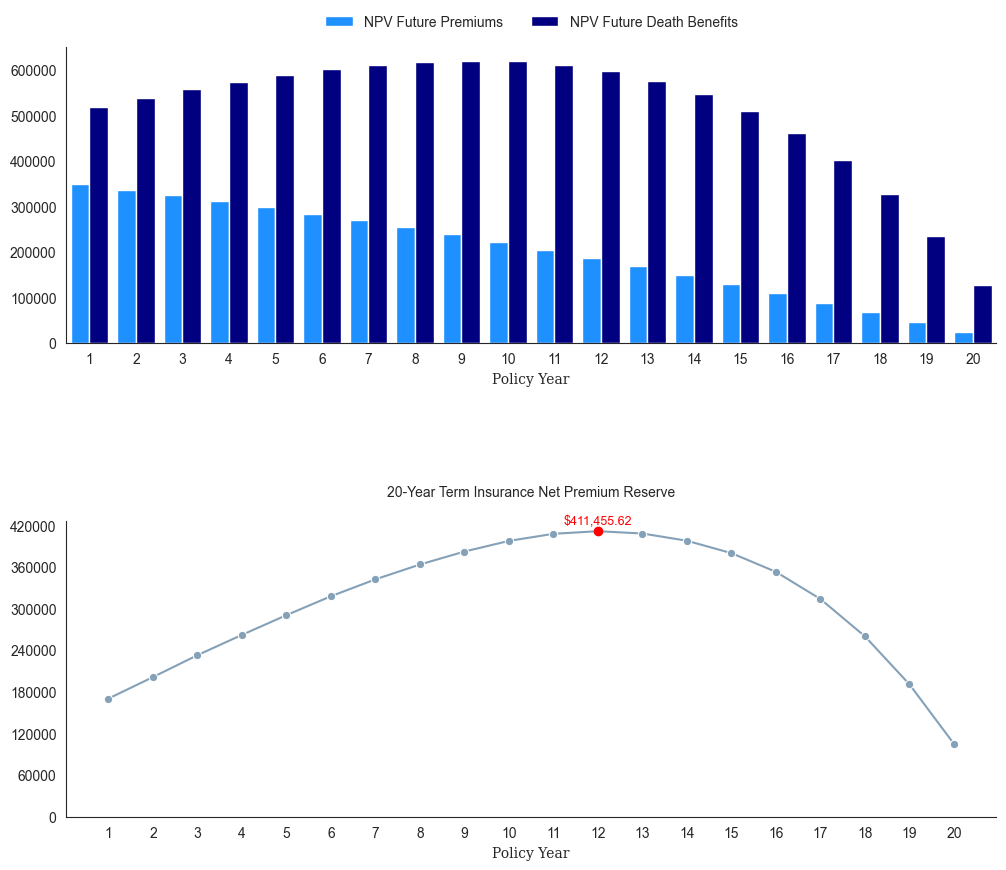

In [86]:
plot_term_reserves(prem_df, 60, 'standard', 'male', 20, 5000000, 0.05)

In [87]:
mask = (prem_df['age'] == 40) & (prem_df['risk_class'] == 'standard')
prem_df[mask]

,mortality,px,qxt,apv,apv_ann_due,pure_prem,age,gender,risk_class,grossprem
52,"[0.00013, 0.00021, 0.00032, 0.00042, 0.00051, ...","[1.0, 0.99987, 0.99966, 0.9993401, 0.9989204, ...","[0.00013, 0.00021, 0.0003199, 0.0004197, 0.000...",0.011459,13.020444,2957.12,40,female,standard,3383.91
53,"[0.00017, 0.0003, 0.00043, 0.00051, 0.00059, 0...","[1.0, 0.99983, 0.9995301, 0.9991003, 0.9985907...","[0.00017, 0.0002999, 0.0004298, 0.0005095, 0.0...",0.014445,13.004517,3732.10,40,male,standard,4245.06
